# ResNet-18 (Augmented + LR Scheduler)

## Changes from Unfreeze Baseline

### What changed
| | Unfreeze | Augmented |
|---|---|---|
| Augmentation | HFlip + ±10° rotation | HFlip + VFlip + ±30° rotation + ColorJitter + RandomAffine |
| Weight decay | None | 1e-4 |
| LR scheduler | None | CosineAnnealingLR |

### Rationale
The unfreeze model overfits heavily — train F2 reaches 0.92 while val F2 stalls around 0.56-0.63. Two changes target this:

1. **Stronger augmentation**: More transforms (vertical flip, wider rotation, color jitter, affine shifts) force the model to learn general melanoma features rather than memorizing specific training images. Skin lesion images have no natural orientation, so flips and rotations are valid.

2. **Weight decay + cosine LR schedule**: Weight decay (L2 regularization) penalizes large weights to prevent overfitting. Cosine annealing gradually reduces the learning rate, allowing the model to settle into a better minimum rather than oscillating.

In [18]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch

In [19]:
use_mps = True
print('MPS available:', torch.backends.mps.is_available())
device = torch.device('mps' if (use_mps and torch.backends.mps.is_available()) else 'cpu')
print(f'Using device: {device}')

MPS available: True
Using device: mps


In [20]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv='../data/splits/train.csv',
    val_csv='../data/splits/val.csv',
    test_csv='../data/splits/test.csv',
    image_dir='../data/raw/HAM10000/images',
    batch_size=32,
    image_size=224,
    num_workers=0,
    transform_train=get_augmented_train_transforms(image_size=224),
)

train_df = pd.read_csv('../data/splits/train.csv')

num_melanoma = (train_df['label'] == 0).sum()   # melanoma in CSV
num_nevus = (train_df['label'] == 1).sum()      # nevus in CSV

pos_weight = torch.tensor([num_nevus / num_melanoma], dtype=torch.float32).to(device)

print('Positive weight:', pos_weight)

model = get_resnet(num_classes=1, freeze_backbone=False).to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

num_epochs = 20
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

Positive weight: tensor([6.0244], device='mps:0')


In [21]:
best_val_f2 = 0.0

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
train_recalls = []
val_recalls = []
train_f2s = []
val_f2s = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_losses.append(train_metrics['loss'])
    val_losses.append(val_metrics['loss'])
    train_accuracies.append(train_metrics['accuracy'])
    val_accuracies.append(val_metrics['accuracy'])
    train_recalls.append(train_metrics['recall'])
    val_recalls.append(val_metrics['recall'])
    train_f2s.append(train_metrics['f2'])
    val_f2s.append(val_metrics['f2'])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Acc: {train_metrics['accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Acc: {val_metrics['accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}"
    )

    if val_metrics['f2'] > best_val_f2:
        best_val_f2 = val_metrics['f2']
        torch.save(model.state_dict(), '../models/resnet_augmented_best.pth')
        print('Saved best model at epoch', epoch+1)

Epoch [1/20] | Train Loss: 0.7609, Acc: 0.7515, Recall: 0.8537, F2: 0.6614 | Val Loss: 0.7026, Acc: 0.8602, Recall: 0.7066, F2: 0.6548
Saved best model at epoch 1
Epoch [2/20] | Train Loss: 0.6477, Acc: 0.8010, Recall: 0.8447, F2: 0.6938 | Val Loss: 0.7016, Acc: 0.8517, Recall: 0.7246, F2: 0.6598
Saved best model at epoch 2
Epoch [3/20] | Train Loss: 0.6179, Acc: 0.8035, Recall: 0.8498, F2: 0.6989 | Val Loss: 0.6416, Acc: 0.8542, Recall: 0.7605, F2: 0.6857
Saved best model at epoch 3
Epoch [4/20] | Train Loss: 0.5778, Acc: 0.8258, Recall: 0.8716, F2: 0.7304 | Val Loss: 0.6056, Acc: 0.8295, Recall: 0.8024, F2: 0.6914
Saved best model at epoch 4
Epoch [5/20] | Train Loss: 0.5820, Acc: 0.8216, Recall: 0.8755, F2: 0.7291 | Val Loss: 0.6076, Acc: 0.8500, Recall: 0.8263, F2: 0.7240
Saved best model at epoch 5
Epoch [6/20] | Train Loss: 0.5332, Acc: 0.8441, Recall: 0.8845, F2: 0.7542 | Val Loss: 0.6227, Acc: 0.7928, Recall: 0.8563, F2: 0.6942
Epoch [7/20] | Train Loss: 0.5058, Acc: 0.8394, Re

## Plot Loss and Accuracy Curves

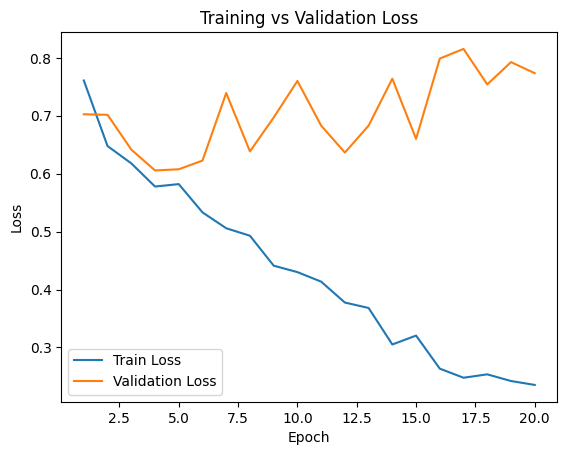

In [22]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

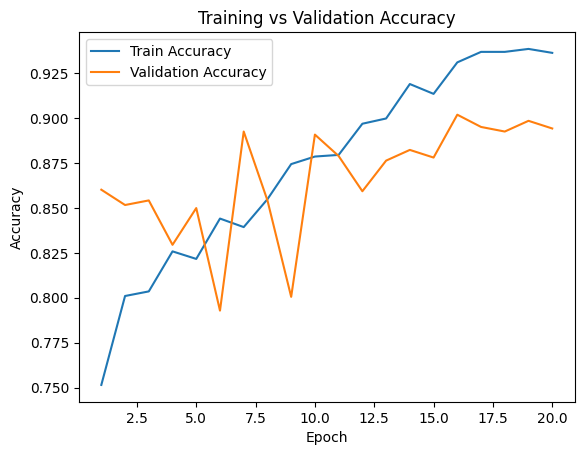

In [23]:
plt.figure()
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

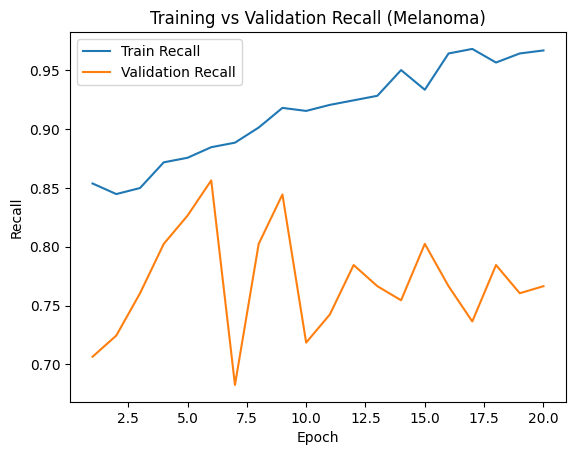

In [24]:
plt.figure()
plt.plot(epochs, train_recalls, label='Train Recall')
plt.plot(epochs, val_recalls, label='Validation Recall')
plt.xlabel('Epoch')
plt.ylabel('Recall')
plt.title('Training vs Validation Recall (Melanoma)')
plt.legend()
plt.show()

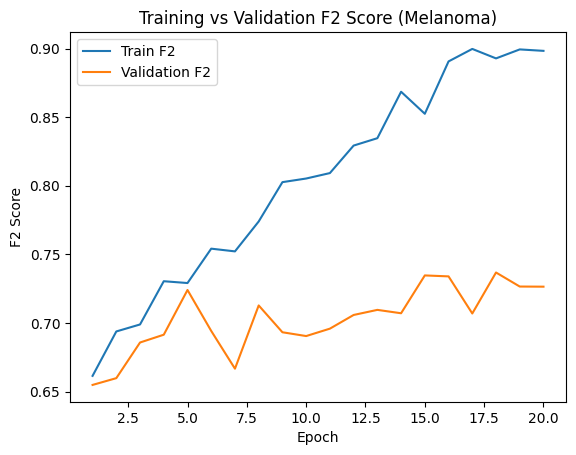

In [25]:
plt.figure()
plt.plot(epochs, train_f2s, label='Train F2')
plt.plot(epochs, val_f2s, label='Validation F2')
plt.xlabel('Epoch')
plt.ylabel('F2 Score')
plt.title('Training vs Validation F2 Score (Melanoma)')
plt.legend()
plt.show()

## Threshold Tuning

In [26]:
import numpy as np
from sklearn.metrics import fbeta_score

model.load_state_dict(torch.load('../models/resnet_augmented_best.pth', map_location=device))
model.eval()

val_probs = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images.to(device))
        probs = torch.sigmoid(outputs).squeeze(1)
        val_probs.extend(probs.cpu().numpy())
        val_labels.extend(labels.numpy())

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [fbeta_score(val_labels, (np.array(val_probs) >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]

best_threshold = thresholds[np.argmax(f2_scores)]
print(f"Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}")

Best threshold: 0.38 | Val F2: 0.7409


In [27]:
from sklearn.metrics import confusion_matrix, classification_report

model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).squeeze(1)
        preds = (probs >= best_threshold).long()

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [28]:
cm = confusion_matrix(all_labels, all_preds)
print('Confusion Matrix:')
print(cm)

Confusion Matrix:
[[916  90]
 [ 23 144]]


[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

In [29]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9755    0.9105    0.9419      1006
           1     0.6154    0.8623    0.7182       167

    accuracy                         0.9037      1173
   macro avg     0.7954    0.8864    0.8301      1173
weighted avg     0.9242    0.9037    0.9101      1173



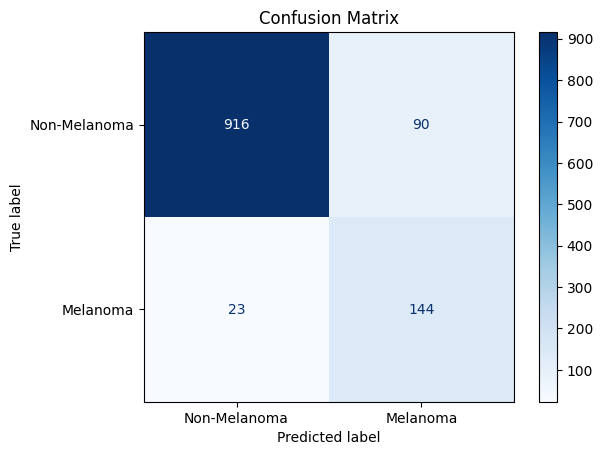

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Melanoma', 'Melanoma'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()